In [32]:
!pip install -q transformers==4.41.2 peft==0.11.1 accelerate==0.31.0 datasets scikit-learn matplotlib seaborn


In [33]:
import torch, pandas as pd, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers import Trainer, TrainingArguments

from peft import AdaLoraConfig, get_peft_model

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix
)

from sklearn.metrics.pairwise import cosine_similarity

In [36]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

df = pd.read_csv(
    "/content/drive/MyDrive/IMDB Dataset (2 Classes).csv",
    encoding="latin1",
    on_bad_lines="skip"
)[['Text','Sentiment']].dropna()

label_encoder = LabelEncoder()

df['label'] = label_encoder.fit_transform(df['Sentiment'])

print("Label Mapping:")

for i, l in enumerate(label_encoder.classes_):
    print(f"{l}: {i}")

train_texts, temp_texts, train_labels, temp_labels = train_test_split(

    df['Text'].tolist(),
    df['label'].tolist(),

    test_size=0.2,
    random_state=42,
    stratify=df['label']
)

val_texts, test_texts, val_labels, test_labels = train_test_split(

    temp_texts,
    temp_labels,

    test_size=0.5,
    random_state=42,
    stratify=temp_labels
)

print(f"\nTrain={len(train_texts)} | Val={len(val_texts)} | Test={len(test_texts)}")

Mounted at /content/drive
Label Mapping:
negative: 0
positive: 1

Train=40000 | Val=5000 | Test=5000


In [37]:
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

train_enc = tokenizer(train_texts, truncation=True, padding=True, max_length=256)
val_enc   = tokenizer(val_texts, truncation=True, padding=True, max_length=256)
test_enc  = tokenizer(test_texts, truncation=True, padding=True, max_length=256)


class SentimentDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        return {
            k: torch.tensor(v[idx]) for k,v in self.encodings.items()
        } | {
            "labels": torch.tensor(self.labels[idx])
        }

    def __len__(self):
        return len(self.labels)


train_ds = SentimentDataset(train_enc, train_labels)
val_ds   = SentimentDataset(val_enc, val_labels)
test_ds  = SentimentDataset(test_enc, test_labels)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [38]:
def compute_metrics(eval_pred):

    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)

    acc = accuracy_score(labels, preds) * 100

    prec, rec, f1, _ = precision_recall_fscore_support(
        labels,
        preds,
        average="binary"
    )

    return {
        "Accuracy": acc,
        "Precision": prec * 100,
        "Recall": rec * 100,
        "F1 Score": f1 * 100
    }

In [39]:
model = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=len(label_encoder.classes_)
)

adalora_cfg = AdaLoraConfig(
    init_r=12,
    target_r=4,
    beta1=0.85,
    beta2=0.85,
    tinit=200,
    tfinal=1000,
    deltaT=10,
    lora_alpha=32,
    lora_dropout=0.1,
    task_type="SEQ_CLS",
    target_modules=["query", "value"]
)

model = get_peft_model(model, adalora_cfg)

args = TrainingArguments(
    output_dir="./adalora-bert",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-4,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    fp16=True,
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    compute_metrics=compute_metrics
)

train_output = trainer.train()
metrics = trainer.evaluate(test_ds)

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.12/dist-packages/accelerate/accelerator.py:477: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler(**kwargs)


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1 score
1,0.282700,0.288836,89.860000,89.247735,90.640000,89.938480
2,0.250900,0.262930,90.360000,91.797846,88.640000,90.191290
3,0.225400,0.260406,90.640000,89.533074,92.040000,90.769231


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


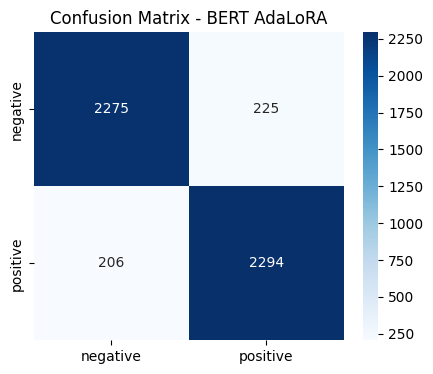

In [41]:
preds_out = trainer.predict(test_ds)

preds = np.argmax(
    preds_out.predictions,
    axis=1
)

cm = confusion_matrix(
    test_ds.labels,
    preds
)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title("Confusion Matrix - BERT AdaLoRA")

plt.show()

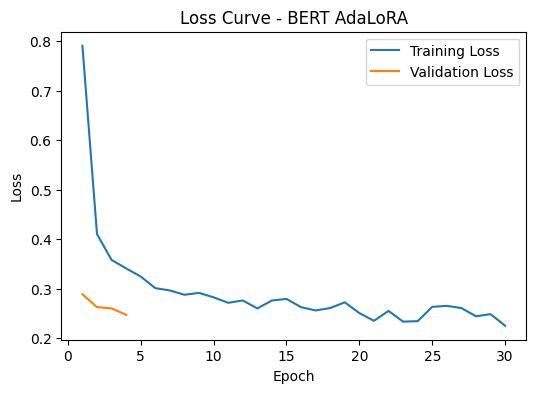

In [40]:
history = trainer.state.log_history

train_loss = [x["loss"] for x in history if "loss" in x]
eval_loss = [x["eval_loss"] for x in history if "eval_loss" in x]

plt.figure(figsize=(6,4))

plt.plot(
    range(1, len(train_loss)+1),
    train_loss,
    label="Training Loss"
)

plt.plot(
    range(1, len(eval_loss)+1),
    eval_loss,
    label="Validation Loss"
)

plt.title("Loss Curve - BERT AdaLoRA")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()

plt.show()

In [42]:
probs = torch.nn.functional.softmax(
    torch.tensor(preds_out.predictions),
    dim=1
)

confidence = probs.max(dim=1).values.numpy().mean() * 100

labels_onehot = np.eye(len(label_encoder.classes_))[test_ds.labels]

similarity = cosine_similarity(
    preds_out.predictions,
    labels_onehot
).mean() * 100


results = {

    "Model": "AdaLoRA BERT",

    "Accuracy": f"{metrics['eval_Accuracy']:.2f}%",
    "Precision": f"{metrics['eval_Precision']:.2f}%",
    "Recall": f"{metrics['eval_Recall']:.2f}%",
    "F1 Score": f"{metrics['eval_F1 Score']:.2f}%",

    "Similarity": f"{similarity:.2f}%",
    "Confidence": f"{confidence:.2f}%",

    "Training Time (s)": f"{train_output.metrics['train_runtime']:.4f}",

    "Trainable Params": sum(
        p.numel() for p in model.parameters() if p.requires_grad
    ),

    "GPU Memory (GB)": f"{torch.cuda.max_memory_allocated()/1024**3:.6f}"
}

df_results = pd.DataFrame([results])

print("\n==============================")
print("IMDB BERT RESULTS")
print("==============================")

print(df_results.to_string(index=False))


IMDB BERT RESULTS
       Model Accuracy Precision Recall F1 Score Similarity Confidence Training Time (s)  Trainable Params GPU Memory (GB)
AdaLoRA BERT   91.38%    91.07% 91.76%   91.41%      8.10%     95.70%         1804.0928            444194        1.236435
